<a href="https://colab.research.google.com/github/Amna-Sarfaraz/Python/blob/studentperformance/kidney_disease.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [81]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [82]:
df=pd.read_csv('/content/kidney_disease.csv')
df.head()

,id,age,bp,sg,al,su,rbc,pc,pcc,ba,...,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
0,0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,...,44,7800,5.2,yes,yes,no,good,no,no,ckd
1,1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,...,38,6000,NaN,no,no,no,good,no,no,ckd
2,2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,...,31,7500,NaN,no,yes,no,poor,no,yes,ckd
3,3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,...,32,6700,3.9,yes,no,no,poor,yes,yes,ckd
4,4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,...,35,7300,4.6,no,no,no,good,no,no,ckd


In [83]:
df.isnull().sum()

,0
id,0
age,9
bp,12
sg,47
al,46
su,49
rbc,152
pc,65
pcc,4
ba,4


In [84]:
median_columns=['age','bp','al','su','bgr','bu','sc','hemo','pcv','wc','rc']
for i in median_columns:
  df[i] = pd.to_numeric(df[i], errors='coerce')

  df[i].fillna(df[i].median(),inplace=True)

/tmp/ipython-input-2172097336.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[i].fillna(df[i].median(),inplace=True)


In [85]:
mean_columns=['sg','sod','pot']
for i in mean_columns:
  df[i] = pd.to_numeric(df[i], errors='coerce')

  df[i].fillna(df[i].mean(),inplace=True)

/tmp/ipython-input-3297002567.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[i].fillna(df[i].mean(),inplace=True)


In [86]:
mode_columns=['rbc','pc','pcc','ba','htn','dm','cad','appet','pe','ane']
for i in mode_columns:
  df[i].fillna(df[i].mode()[0],inplace=True)

/tmp/ipython-input-350655013.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[i].fillna(df[i].mode()[0],inplace=True)


In [87]:
print(df.isnull().sum())

id                0
age               0
bp                0
sg                0
al                0
su                0
rbc               0
pc                0
pcc               0
ba                0
bgr               0
bu                0
sc                0
sod               0
pot               0
hemo              0
pcv               0
wc                0
rc                0
htn               0
dm                0
cad               0
appet             0
pe                0
ane               0
classification    0
dtype: int64


In [88]:
num_cols = ['age','bp','sg','al','su','bgr','bu','sc','sod','pot','hemo','pcv','wc','rc']
for i in num_cols:
  mean=np.mean(df[i])
  std=np.std(df[i])
  min=np.min(df[i])
  max=np.max(df[i])
  print(f"{i} : Mean= {mean}, Std= {std}, min= {min}, max= {max}")


age : Mean= 51.5625, Std= 16.9617538524175, min= 2.0, max= 90.0
bp : Mean= 76.575, Std= 13.47291263981169, min= 50.0, max= 180.0
sg : Mean= 1.0174079320113314, Std= 0.0053626620698977836, min= 1.005, max= 1.025
al : Mean= 0.9, Std= 1.3114877048603923, min= 0.0, max= 5.0
su : Mean= 0.395, Std= 1.038737214121069, min= 0.0, max= 5.0
bgr : Mean= 145.0625, Std= 75.16663883499115, min= 22.0, max= 490.0
bu : Mean= 56.693000000000005, Std= 49.33347546038086, min= 1.5, max= 391.0
sc : Mean= 2.9971249999999996, Std= 5.621845603035994, min= 0.4, max= 76.0
sod : Mean= 137.52875399361022, Std= 9.192760903838618, min= 4.5, max= 163.0
pot : Mean= 4.62724358974359, Std= 2.8162556832997176, min= 2.5, max= 47.0
hemo : Mean= 12.5425, Std= 2.713092101274852, min= 3.1, max= 17.8
pcv : Mean= 39.0825, Std= 8.152036172024756, min= 9.0, max= 54.0
wc : Mean= 8298.5, Std= 2526.4298426831488, min= 2200.0, max= 26400.0
rc : Mean= 4.73775, Std= 0.8403867785133234, min= 2.1, max= 8.0


In [89]:
df['BMI'] = np.random.uniform(15, 40, size=len(df))
df['BMI_Category'] = np.where(df['BMI'] < 18.5, 'Underweight',
                       np.where(df['BMI'] < 25, 'Normal weight',
                       np.where(df['BMI'] < 30, 'Overweight', 'Obese')))

print(df[['BMI', 'BMI_Category']].head())

         BMI   BMI_Category
0  36.696531          Obese
1  35.497770          Obese
2  39.442021          Obese
3  21.300047  Normal weight
4  34.857689          Obese


In [90]:
le=LabelEncoder()
encoding = [
    'rbc',
    'pc',
    'pcc',
    'ba',
    'htn',
    'dm',
    'cad',
    'appet',
    'pe',
    'ane',
    'BMI_Category',
]
for i in encoding:
  le.fit(df[i])
  df[i]=le.transform(df[i])
df.head()

,id,age,bp,sg,al,su,rbc,pc,pcc,ba,...,rc,htn,dm,cad,appet,pe,ane,classification,BMI,BMI_Category
0,0,48.0,80.0,1.020,1.0,0.0,1,1,0,0,...,5.2,1,4,1,0,0,0,ckd,36.696531,1
1,1,7.0,50.0,1.020,4.0,0.0,1,1,0,0,...,4.8,0,3,1,0,0,0,ckd,35.497770,1
2,2,62.0,80.0,1.010,2.0,3.0,1,1,0,0,...,4.8,0,4,1,1,0,1,ckd,39.442021,1
3,3,48.0,70.0,1.005,4.0,0.0,1,0,1,0,...,3.9,1,3,1,1,1,1,ckd,21.300047,0
4,4,51.0,80.0,1.010,2.0,0.0,1,1,0,0,...,4.6,0,3,1,0,0,0,ckd,34.857689,1


In [91]:
avg_values=df.groupby('classification')[['bgr', 'sc']].mean()
print(avg_values)


                       bgr        sc
classification                      
ckd             167.169355  4.279234
ckd\t           164.500000  2.550000
notckd          108.253333  0.883333


/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


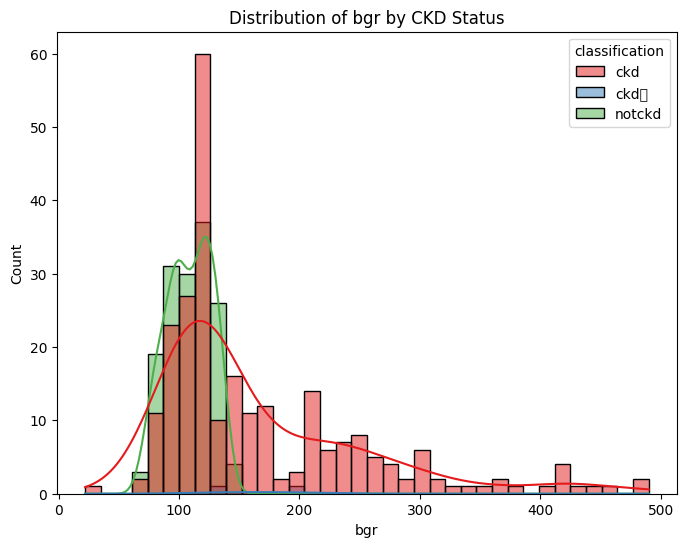

/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


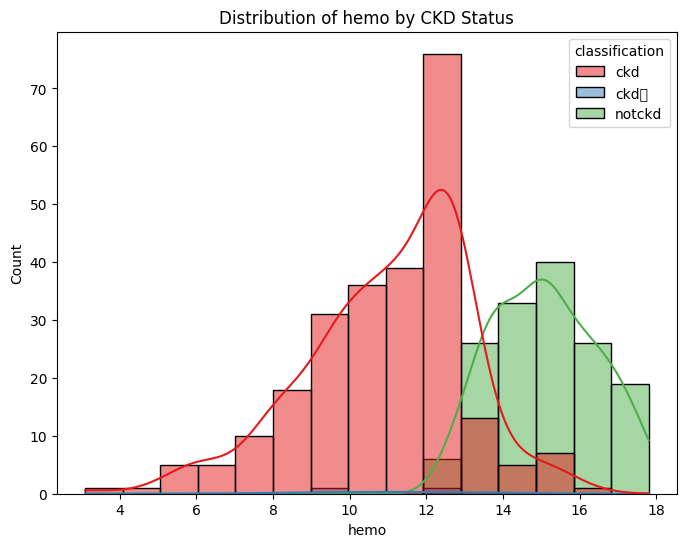

/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


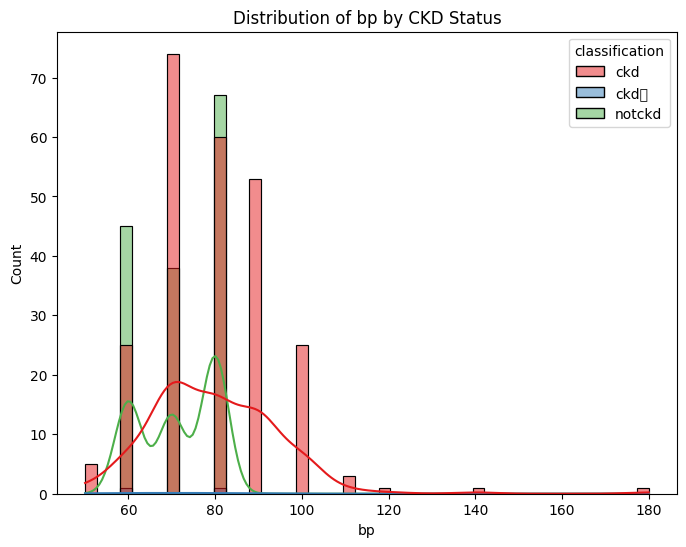

In [92]:
features=['bgr', 'hemo', 'bp']
for col in features:
  plt.figure(figsize=(8, 6))
  sns.histplot(data=df,x=col, hue='classification', kde=True, palette='Set1')
  plt.title(f'Distribution of {col} by CKD Status')
  plt.show()

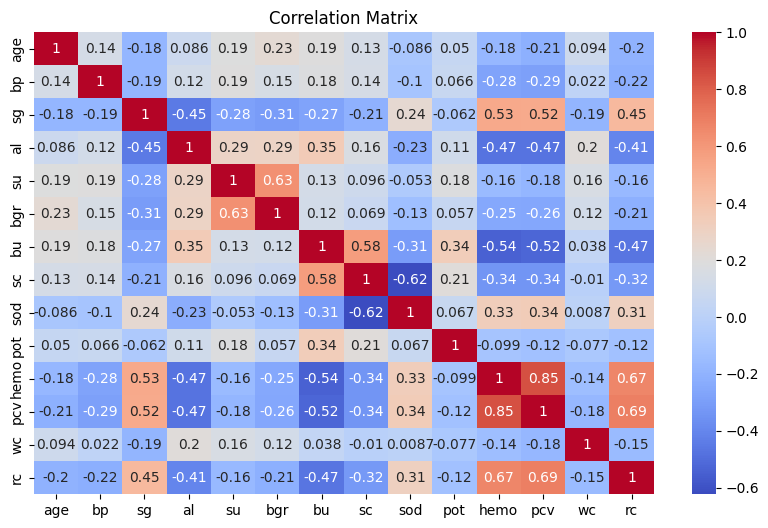

In [93]:
num_cols = ['age','bp','sg','al','su','bgr','bu','sc','sod','pot','hemo','pcv','wc','rc']
corr_matrix = df[num_cols].corr()
plt.figure(figsize=(10,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


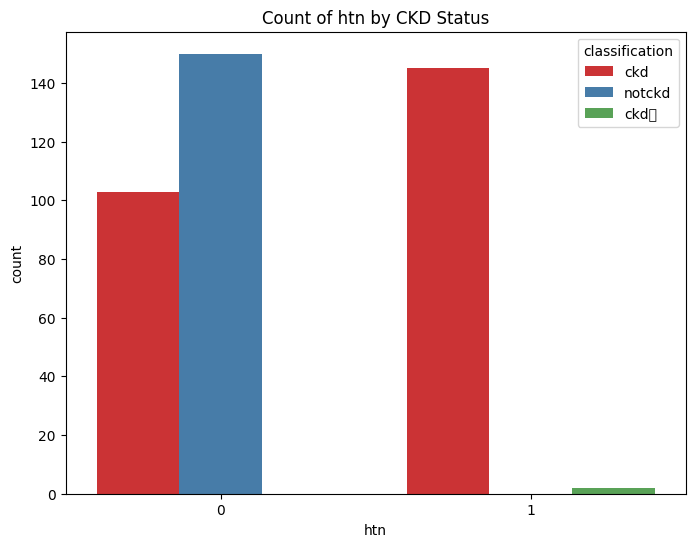

/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


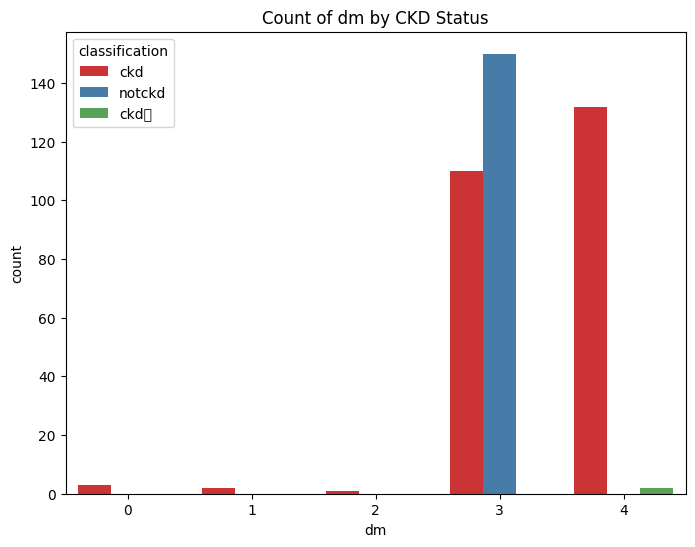

In [94]:
categorical_cols = ['htn', 'dm']
for col in categorical_cols:
  plt.figure(figsize=(8, 6))
  sns.countplot(data=df, x=col, hue='classification', palette='Set1')
  plt.title(f'Count of {col} by CKD Status')
  plt.show()


In [95]:
X=df.drop(['classification','id'],axis=1)
y=df['classification']
model=LogisticRegression()
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
model.fit(X_train,y_train)
y_pred=model.predict(X_test)

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [96]:
print("Accuracy: ",accuracy_score(y_test,y_pred))
print("Classification Report:\n",classification_report(y_test,y_pred))
print("Confusion Matrix:\n",confusion_matrix(y_test,y_pred))

Accuracy:  0.8875
Classification Report:
               precision    recall  f1-score   support

         ckd       0.91      0.92      0.91        52
      notckd       0.85      0.82      0.84        28

    accuracy                           0.89        80
   macro avg       0.88      0.87      0.88        80
weighted avg       0.89      0.89      0.89        80

Confusion Matrix:
 [[48  4]
 [ 5 23]]


In [97]:

array_test=np.array(y_test[:5])
print("Test: ",array_test)
print("Predication: ",y_pred[:5])

Test:  ['ckd' 'notckd' 'ckd' 'ckd' 'ckd']
Predication:  ['ckd' 'notckd' 'ckd' 'ckd' 'ckd']


In [98]:
import pickle
pickle.dump(model, open("model.pkl", "wb"))

In [99]:
from google.colab import files
files.download('model.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [100]:
import pickle

# Your median, mean, and mode values you already use in your code
median_values = {
    'age': 50, 'bp': 80, 'al': 0, 'su': 0, 'bgr': 100,
    'bu': 40, 'sc': 1.2, 'hemo': 13.0, 'pcv': 40, 'wc': 8000, 'rc': 4.5
}

mean_values = {'sg': 1.015, 'sod': 138.0, 'pot': 4.2}

mode_values = {
    'rbc': 0, 'pc': 0, 'pcc': 0, 'ba': 0, 'htn': 0,
    'dm': 0, 'cad': 0, 'appet': 1, 'pe': 0, 'ane': 0
}

# If you used LabelEncoders during training, save them here
# For example:
# label_encoders = {'htn': htn_encoder, 'dm': dm_encoder, ...}
# If not, just keep it empty or omit
label_encoders = {}

preprocess = {
    "median_values": median_values,
    "mean_values": mean_values,
    "mode_values": mode_values,
    "label_encoders": label_encoders
}

with open("preprocess.pkl", "wb") as f:
    pickle.dump(preprocess, f)

print("preprocess.pkl saved!")
from google.colab import files
files.download('preprocess.pkl')

preprocess.pkl saved!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>